# Project: Information Retrieval System for MS MARCO

**Course:** Multimedia Information Retrieval and Computer vision  
**Students:** Malik Muhammad Uzair, Bashar Hayani


This project implements a complete, in-memory Information Retrieval (IR) system from scratch. The goal is to build and evaluate a system capable of handling the large-scale **MS MARCO Passage Ranking dataset** (8.8 million passages).


# 1. Project Setup and Environment

This section prepares the environment for our Information Retrieval project.

## 1.1 Install Dependencies and Import Libraries

The first step is to install all necessary Python packages and import the modules required for the entire pipeline. This includes:

* **Core IR Libraries:** `python-terrier`, `ir_datasets`, and `ir_measures` for data handling, benchmarking, and evaluation.
* **NLP Tools:** `nltk` for stopword lists and `PyStemmer` for efficient word stemming.
* **Data Handling:** `polars` and `numpy` for high-performance data manipulation and large-scale array operations.
* **Utilities:** `gdown` for downloading the corpus and standard data science libraries like `pandas`, `matplotlib`, and `tqdm`.

In [ ]:
# Install the core IR libraries
!pip install -q python-terrier ir_datasets ir_measures polars PyStemmer numpy pandas matplotlib seaborn scipy
# Install required NLP packages
!pip install -q nltk

# --- Standard Imports ---
import ir_datasets
import ir_measures
from ir_measures import nDCG, AP, RR, P, Judged, Recall
import re
import Stemmer
import nltk
import gdown
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import time
import heapq
import math
import random
import os
import pickle
import itertools
from functools import lru_cache
from collections import defaultdict, Counter
from tqdm.auto import tqdm
from scipy import stats as st
from tabulate import tabulate
import matplotlib.pyplot as plt
# Initialize NLTK components
nltk.download("stopwords", quiet=True)

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.0/168.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.3/745.3 kB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.0/149.0 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 32.8 MB/s eta 0:00:00


True

## 1.3 Profiling and Performance Measurement

In Information Retrieval, both **effectiveness** (ranking quality) and **efficiency** (speed) are critical metrics. This decorator is a reusable utility designed to accurately measure the execution time of any function it wraps.

In [ ]:
def profile(f):
    def f_timer(*args, **kwargs):
        start = time.time()
        result = f(*args, **kwargs)
        end = time.time()
        elapsed_time = end - start

        if elapsed_time >= 60:  # If the time is more than a minute
            minutes = int(elapsed_time // 60)
            seconds = elapsed_time % 60
            print(f"{f.__name__}: {minutes} min {seconds:.3f} s")
        elif elapsed_time >= 1:  # If the time is more than a second
            print(f"{f.__name__}: {elapsed_time:.3f} s")
        else:  # If the time is less than a second
            print(f"{f.__name__}: {elapsed_time * 1000:.3f} ms")

        return result

    return f_timer

# 2. Collection Loading and Data Preparation

## 2.1 MS MARCO

The efficiency and effectiveness of our search engine are founded on the document collection it searches. For this project, we utilize the full **MS MARCO (Machine Reading COmprehension) Passage Collection**, which is the gold standard benchmark for modern large-scale retrieval systems.



To successfully manage this data within the Colab environment:
* We use the **`gdown`** utility to retrieve the large, uncompressed TSV file (approximately 3GB).
* We employ the **Polars** DataFrame library for loading. Polars is essential for its superior speed and memory efficiency when reading Tab-Separated Values (TSV) files, allowing us to handle the $8.8$ million rows without crashing the system's memory.
* During loading, we perform initial data integrity checks by filtering out any passages that are null or empty.

In [ ]:
# --- Configuration for MS MARCO Corpus ---
COLLECTION_URL = 'https://drive.google.com/file/d/1y0ma-oRGSVHmgSyV2Bj4qjVqSAC46LOZ/view?usp=sharing'
COLLECTION_PATH = "collection.tsv"

# Download the Corpus
if not os.path.exists(COLLECTION_PATH):
    print("Downloading MS MARCO Passages Corpus (Approx. 3GB)...")
    # gdown is used for large Google Drive files. The quiet=False ensures you see the progress.
    # Note: This is a large file and may take several minutes depending on your connection.
    try:
        gdown.download(
            url=COLLECTION_URL,
            output=COLLECTION_PATH,
            fuzzy=True,
            quiet=False
        )
    except Exception as e:
        print(f"Error during download: {e}")
        print("Please check the link or try manually downloading and uploading 'collection.tsv' to your Colab directory.")
else:
    print("Corpus file 'collection.tsv' already exists.")

# Load the Corpus into a Polars DataFrame
# Polars (pl) is used here for its speed and memory efficiency with large TSV files.
if os.path.exists(COLLECTION_PATH):

    print("\nLoading corpus into Polars DataFrame for efficient processing...")

    # scan_csv starts a lazy operation, and .collect() executes it, reading the file.
    df = (
        pl.read_csv(
            COLLECTION_PATH,
            separator="\t",
            has_header=False,
            # Explicitly name the columns based on the MS MARCO format: <pid> \t <text>
            columns=["column_1", "column_2"],
        )
        # Rename columns to meaningful names
        .rename({"column_1": "docId", "column_2": "text"})
        # Filter out any passages with null or empty text (data cleaning)
        .filter(pl.col("text").is_not_null())
        .filter(pl.col("text").str.strip_chars().str.len_chars() > 0)
    )

    print(f"Loaded {df.height:,} documents into DataFrame.")

else:
    print("Cannot load DataFrame as 'collection.tsv' was not found.")

Downloading...
From (original): https://drive.google.com/uc?id=1y0ma-oRGSVHmgSyV2Bj4qjVqSAC46LOZ
From (redirected): https://drive.google.com/uc?id=1y0ma-oRGSVHmgSyV2Bj4qjVqSAC46LOZ&confirm=t&uuid=d616d3ac-3dfe-43ab-98e2-379480bf9812
To: /content/collection.tsv
100%|██████████| 3.06G/3.06G [00:43<00:00, 69.9MB/s]



Loading corpus into Polars DataFrame for efficient processing...
Loaded 8,841,823 documents into DataFrame.


In [ ]:
for i, row in enumerate(df.sample(5, seed=14).iter_rows(named=True)):
    print(f"[{i+1}] Document: {row['docId']}")
    print(row['text'])
    print("\n")

[1] Document: 8455713
Then I solve the cube as if it were a Rubik's Cube (3x3x3) only I treateach edge piece group as one edge piece, and each center piece group as one center piece. Using thismethod I can solve the revenge, on average, in under 2 minutes each time. My personal record with thismethod is 1 minute 11.27 seconds.olve 2nd pair of centers (4 rows) d Front BackGo to this moveBack to the top 11. Solve 2nd pair of centers (move 1) d F ' d '. Rubik's Revenge Solution Moves List: Step 1 07/16/2007 01:03 AMhttp://www.speedcubing.com/chris/4-movelist1.html Page 4 of 5 Go to this moveBack to the top 12.


[2] Document: 986174
Eukaryotes can be found variously as single-celled organisms called protists, and as organized systems in multicellular organisms. The cells of all plants, animals and fungi are eukaryotes. The prokaryotes live on in the two major divisions of bacteria-the eubacteria and the archebacteria.aluable Lessons. Having established that Giardia occupies an important p

## 2.2. Text Processing

This section executes the single-most critical preparation task: transforming the raw, noisy passage content into a standardized set of terms that the search index can understand and efficiently process. Due to the immense size of the MS MARCO corpus ($8.8$ million documents), our pipeline is designed for maximal **efficiency** and **retrieval effectiveness**. The function `preprocess` executes the required transformations in sequence.
First, **Lexical Normalization** occurs, where the input text is converted entirely to lowercase, ensuring case differences do not affect retrieval results.

Second, **Advanced Token Extraction** is performed; we utilize a specific regular expression pattern (`TOKEN_PATTERN`) to intelligently group elements like hyphenated words and alphanumeric identifiers (e.g., version numbers, abbreviations with periods) into single, meaningful index tokens, which preserves semantic context better than simple whitespace splitting.

Third, **Stopword Removal** is applied; common, non-discriminative words (e.g., 'a', 'the', conjunctions) are excluded using a highly optimized `frozenset` lookup against the NLTK list, reducing the index size and improving focus on valuable keywords.

Finally, **Morphological Reduction (Stemming)** is performed using the **PyStemmer** implementation of the Snowball algorithm to reduce words to their common root form (e.g., "retrieving" $\rightarrow$ "retriev"). This critical component is optimized via the **`@lru_cache`** decorator, which caches the stem for every unique word, preventing redundant stemming computation across the millions of documents and ensuring high-speed index construction.

In [ ]:
# --- Preprocessing Components ---

# Load English stopwords once from NLTK
# frozenset is used for highly efficient lookup
STOP_WORDS = frozenset(nltk.corpus.stopwords.words("english"))

# Initialize fast English stemmer from the PyStemmer library (Snowball algorithm)
stemmer = Stemmer.Stemmer('english')

# Tokenization Pattern: Designed to capture meaningful IR tokens (words, hyphenated terms, numbers)
# re.VERBOSE allows for multi-line comments within the regex for clarity.
TOKEN_PATTERN = re.compile(r'[a-z]+|[a-z]+-[a-z]+|\d+[a-z]+|[a-z]+\d+|[a-z]+\.|\d{4}|\d+\.\d+|\d+', re.IGNORECASE)

# --- Core Functions ---
# Stems a single word using the fast PyStemmer implementation.
# lru_cache is essential here to cache results and avoid repeated stemming of the same word (performance gain on large corpus).
@lru_cache(maxsize=None)
def stem_word(word: str) -> str:
   return stemmer.stemWord(word)


# Applies the complete text preprocessing pipeline
def preprocess(text: str) -> list[str]:
    if not text:
        return []

    # 1. Lowercasing + Tokenization
    text = text.lower()
    text = text.replace("&", " and ")

    # Use the compiled regex pattern to find all tokens in the lowercased text
    tokens = TOKEN_PATTERN.findall(text)

    # 2. Stopword Filtering + 3. Stemming
    # We iterate, filter for tokens longer than 1 character and not in stopwords, then stem.
    cleaned_tokens = [
        stem_word(tok)
        for tok in tokens
        if len(tok) > 1 and tok not in STOP_WORDS
    ]

    return cleaned_tokens

print("Preprocessing pipeline defined.")

Preprocessing pipeline defined.



## 2.2.1 Verify Preprocessing

In [ ]:
test_passage = "The Manhattan Project the hello hello largest scientific and industrial effort in U.S. history; it produced the first atomic weapons in 1945. Retrieving data is key to success."

print(f"Original Text: {test_passage}")
print("-" * 50)
print(f"Processed Tokens:\n{preprocess(test_passage)}")

Original Text: The Manhattan Project the hello hello largest scientific and industrial effort in U.S. history; it produced the first atomic weapons in 1945. Retrieving data is key to success.
--------------------------------------------------
Processed Tokens:
['manhattan', 'project', 'hello', 'hello', 'largest', 'scientif', 'industri', 'effort', 'histori', 'produc', 'first', 'atom', 'weapon', '1945', 'retriev', 'data', 'key', 'success']


## 3.1 Index Construction: Building the Inverted Index

The **Inverted Index** is the foundational data structure of our Information Retrieval system. The `build_index` function below implements a complete single-pass, in-memory indexing algorithm designed for efficiency on the massive **MS MARCO** corpus.

This process sequentially reads every preprocessed passage and simultaneously updates the three core components of the index:

1. **Lexicon** – Maps every unique stemmed term to a unique integer ID, its document frequency ($\text{df}$), and its collection frequency ($\text{cf}$).  
2. **Document Index** – Maintains metadata for each passage, including its original string ID (`DocNO`) and its calculated length ($\text{doc\_length}$), a crucial parameter for **BM25** ranking.  
3. **Postings Lists** – Record the document ID and the consolidated term frequency ($\text{tf}$) for every term occurrence.

Once all **8.8 million** documents have been processed, the temporary Python list-based posting lists are converted into sorted **NumPy arrays**.

This conversion is critical, as it optimizes the index structure for fast lookups and enables the efficient **Document-at-a-Time (DAAT)** search algorithm, maximizing retrieval speed during the querying phase.


In [ ]:
@profile
def build_index(df_corpus: pl.DataFrame) -> tuple:
    """
    Builds a custom in-memory inverted index from the MS MARCO Polars DataFrame.

    Returns: (lexicon, posting_lists, doc_index, stats)
    """
    print(f"Preprocessing {df_corpus.height:,} documents...")

    # --- 1. INITIALIZE DATA STRUCTURES ---

    # Lexicon: Maps a term (str) to a list -> [term_id, doc_frequency, collection_frequency]
    lexicon = {}

    # Temporary posting lists: defaultdict is used for easy appends during the single pass.
    inv_d, inv_f = defaultdict(list), defaultdict(list)

    # Document Index: Stores metadata -> list of (original_doc_id (str), doc_length (int))
    doc_index = []

    # Counters for assigning unique, sequential integer IDs to terms and documents
    next_tid = 0
    internal_docid = 0

    # --- 2. POPULATE INDEX (SINGLE-PASS) ---
    # We iterate over the Polars DataFrame rows.
    for original_doc_id, text in tqdm(
        df_corpus.iter_rows(),
        total=df_corpus.height,
        desc="Building index"
    ):
        # Apply the pre-processing pipeline
        tokens = preprocess(text)
        doclen = len(tokens)

        # Add document metadata to doc_index. Note: doc_id is the internal sequential ID.
        doc_index.append((str(original_doc_id), doclen))

        tf = Counter(tokens)

        # For each unique term in the document, update the lexicon and posting lists
        for tok, f in tf.items():
            if tok not in lexicon:
                # Term is new: assign an ID and initialize stats
                lexicon[tok] = [next_tid, 0, 0] # [term_id, df, cf]
                next_tid += 1

            tid = lexicon[tok][0]

            # Append the current document's internal ID and the term's frequency to the postings
            inv_d[tid].append(internal_docid)
            inv_f[tid].append(f)

            # Update collection-wide statistics for the term
            lexicon[tok][1] += 1  # Increment document frequency (df)
            lexicon[tok][2] += f   # Increment collection frequency (cf)

        internal_docid += 1


    # --- 3. FINALIZE INDEX STRUCTURE ---
    print("\nFinalizing index structure")
    final_inv_d = {}
    final_inv_f = {}
    index_size = 0

    # Convert the temporary Python lists into memory-efficient NumPy arrays
    for tid in tqdm(inv_d.keys(), desc="Converting posting lists"):

        # --- Critical Step for DAAT ---
        # Get the lists of docids and freqs
        docids_list = inv_d[tid]
        freqs_list = inv_f[tid]

        # We need the freqs to match the sorted docids.
        # A full single-pass index ensures this, but here we sort explicitly:

        # Pair docids and freqs, sort by docid, and unpack them back into sorted lists
        paired_postings = sorted(zip(docids_list, freqs_list), key=lambda x: x[0])
        sorted_docids = np.array([p[0] for p in paired_postings], dtype=np.uint32)
        sorted_freqs = np.array([p[1] for p in paired_postings], dtype=np.uint32)

        final_inv_d[tid] = sorted_docids
        final_inv_f[tid] = sorted_freqs

        # Track the total memory size of the posting lists.
        index_size += sorted_docids.nbytes + sorted_freqs.nbytes

    # Compile final statistics about the collection and the created index.
    stats = {
        "num_docs": len(doc_index),
        "num_terms": len(lexicon),
        "num_tokens": sum(dl for _, dl in doc_index),
        "index_size_mb": index_size / (1024 * 1024),
    }

    print(f"\nIndexing Complete:")
    print(f"   Documents indexed: {stats['num_docs']:,}")
    print(f"   Unique terms: {stats['num_terms']:,}")
    print(f"   Index size: {stats['index_size_mb']:.1f} MB")

    return lexicon, {"docids": final_inv_d, "frequencies": final_inv_f}, doc_index, stats

## 3.2 Building the Inverted Index
  
The following code triggers the `build_index()` function, which sequentially processes all passages, updates the **Lexicon**, **Inverted Index**, and **Document Index**, and returns key indexing statistics.  

Once the index is successfully built, the original DataFrame is deleted from memory to free up system resources.


In [ ]:

print("\nStarting Index Building on MS MARCO Corpus...")
# Execute the build_index function and capture the components
lex, inv, doc, stats = build_index(df)
print("\nIndex Build")
del df
gc.collect()


Starting Index Building on MS MARCO Corpus...
Preprocessing 8,841,823 documents...


Building index:   0%|          | 0/8841823 [00:00<?, ?it/s]


Finalizing index structure


Converting posting lists:   0%|          | 0/1199288 [00:00<?, ?it/s]


Indexing Complete:
   Documents indexed: 8,841,823
   Unique terms: 1,199,288
   Index size: 1686.7 MB
build_index: 17 min 49.246 s

Index Build


1199328

### 3.2.1 Inspecting the Built Inverted Index

After constructing the inverted index, it’s essential to verify that all core components — the **Lexicon**, **Postings Lists**, and **Document Index** — have been built correctly.  
The following code cell performs a quick inspection of the index by:

1. Displaying key **index statistics** such as the total number of documents, terms, and overall size.  
2. Sampling a few **lexicon entries** to show how terms are mapped to their IDs, document frequencies (DF), and collection frequencies (CF).  
3. Selecting a **random term** and displaying its corresponding **posting list** (a list of document IDs and term frequencies).  
4. Displaying random samples from the **Document Index** to check document identifiers and their computed lengths.

This step provides a sanity check to ensure that the indexing pipeline has correctly processed and organized the MS MARCO corpus before moving on to query processing and retrieval.


In [ ]:

# Display summary statistics
print("=== Index Summary ===")
for k, v in stats.items():
    print(f"{k:15}: {v}")


# Preview random entries from the lexicon
print("\n=== Sample of Lexicon Entries ===")

# Randomly sample up to 10 terms (or all if lexicon is smaller)
sample_terms = random.sample(list(lex.items()), k=min(10, len(lex)))

for i, (term, data) in enumerate(sample_terms, 1):
    term_id, df, cf = data
    print(f"{i}. Term: '{term}' | Term ID: {term_id} | DF: {df} | CF: {cf}")


# Pick a random term ID
sample_tid = random.choice(list(inv["docids"].keys()))

# Reverse lookup to find the corresponding term string
sample_term = next(term for term, data in lex.items() if data[0] == sample_tid)
print(f"\n=== Sample Postings for Term '{sample_term}' (Term ID: {sample_tid}) ===")
print("DocIDs:", inv["docids"][sample_tid][:10])  # first 10 document IDs
print("Freqs :", inv["frequencies"][sample_tid][:10])  # corresponding term frequencies


# Show random entries from the document index
print("\n=== Sample of Document Index Entries ===")

# Randomly sample up to 5 entries (or fewer if the index is small)
sample_docs = random.sample(doc, k=min(5, len(doc)))

for i, (docno, doclen) in enumerate(sample_docs, 1):
    print(f"{i}. DocNO: {docno} | Doc Length: {doclen}")



=== Index Summary ===
num_docs       : 8841823
num_terms      : 1199288
num_tokens     : 294446080
index_size_mb  : 1686.7386093139648

=== Sample of Lexicon Entries ===
1. Term: 'maihuenia' | Term ID: 622821 | DF: 3 | CF: 3
2. Term: 'civilservic' | Term ID: 496039 | DF: 3 | CF: 3
3. Term: '28.24' | Term ID: 268903 | DF: 13 | CF: 14
4. Term: 'dimat' | Term ID: 897079 | DF: 1 | CF: 1
5. Term: 'rupal' | Term ID: 94482 | DF: 20 | CF: 23
6. Term: 'yuli' | Term ID: 400277 | DF: 11 | CF: 14
7. Term: 'ccozen' | Term ID: 812581 | DF: 2 | CF: 2
8. Term: 'kotak' | Term ID: 407038 | DF: 30 | CF: 64
9. Term: 'hagg' | Term ID: 103141 | DF: 14 | CF: 16
10. Term: 'iscar' | Term ID: 961180 | DF: 2 | CF: 2

=== Sample Postings for Term 'baryphonia' (Term ID: 1015639) ===
DocIDs: [6918258 7553414]
Freqs : [1 1]

=== Sample of Document Index Entries ===
1. DocNO: 5634870 | Doc Length: 36
2. DocNO: 3151654 | Doc Length: 16
3. DocNO: 1569688 | Doc Length: 18
4. DocNO: 8338854 | Doc Length: 24
5. DocNO: 243

## 4.1 TopQueue


A priority queue (implemented as a **min-heap**) that maintains the **K best (highest-scoring)** documents encountered so far.  
Its key optimization is the **`threshold`** attribute, which stores the score of the *K-th best* document.  
Any new document scoring **at or below this threshold** can be immediately discarded, improving efficiency during ranking.



In [ ]:

# --- TopQueue: Min-Heap for Top-K Management ---
class TopQueue:
    """
    Manages the top-K scoring documents efficiently using a min-heap.
    It uses a dynamic threshold to quickly discard low-scoring documents.
    """
    def __init__(self, k=10):
        self.queue = []  # Min-heap stores (score, -docid) for tie-breaking
        self.k = k
        self.threshold = 0.0

    def size(self):
        return len(self.queue)

    def insert(self, docid, score):
        # We negate docid for secondary sorting: lower scores are minimized, but
        # for tied scores (which are rare), the higher (less negative) -docid
        # (i.e., the lower original docid) is prioritized.
        item = (score, -docid)

        if self.size() < self.k:
            heapq.heappush(self.queue, item)
        else:
            # Check if the score beats the current minimum score (the threshold)
            if score > self.threshold:
                # Insert the new item and pop the minimum item (the one with the lowest score)
                heapq.heappushpop(self.queue, item)
                self.threshold = self.queue[0][0] # Update the threshold to the new minimum

    def get_top_k(self, sorted_desc=True):
        """Retrieves and sorts the final top-K results."""
        # Unpack the stored (score, -neg_docid) tuples
        unpacked_items = [(score, -neg_docid) for score, neg_docid in self.queue]

        if sorted_desc:
            # Sort by score (descending) and then docid (ascending)
            return sorted(unpacked_items, key=lambda x: (x[0], -x[1]), reverse=True)
        return unpacked_items


## 4.2 Posting List Iterator
To efficiently process queries, we must iterate through the inverted index's posting lists (the list of documents containing a term).

The PostingListIterator class is a stateful object that acts as an optimized "cursor" for a single term's posting list. Its most critical feature is the next(target_docid) method, which uses NumPy's searchsorted (a binary search) to instantly "skip" the cursor to the next document ID at or after a specific target.

In [ ]:
# --- PostingListIterator (for DAAT Traversal) ---
class PostingListIterator:
    """
    Stateful object for traversing a single term's posting list.
    It enables fast score calculation and 'skip' functionality via NumPy's searchsorted.
    """
    def __init__(self, docids, freqs, doc_index, collection_stats, df):
        # Direct NumPy array references for speed
        self.docids = docids
        self.freqs = freqs

        self.doc_index = doc_index
        self.num_docs = collection_stats['num_docs']
        self.total_dl = collection_stats['num_tokens']
        self.df = df # Term's document frequency

        self.pos = 0 # Current position pointer

    def docid(self):
        """Returns the current document ID or math.inf if list is exhausted."""
        if self.is_end_list():
            return math.inf
        # docids are stored as sequential integers (0, 1, 2, ...)
        return int(self.docids[self.pos])

    def next(self, target=None):
        """Advances the iterator, skipping to the target docID if provided (DAAT optimization)."""
        if not target:
            if not self.is_end_list():
                self.pos += 1
        elif target > self.docid():
            # NumPy binary search for efficient skipping: finds the index of the target
            idx = np.searchsorted(self.docids[self.pos:], target)
            self.pos = min(self.pos + idx, len(self.docids))

    def is_end_list(self):
        """Checks if the pointer has reached the end of the posting list."""
        return self.pos >= len(self.docids)

    def get_tf(self):
        """Returns the term frequency for the current document."""
        return int(self.freqs[self.pos]) if not self.is_end_list() else 0

    def get_doclen(self):
        """Returns the document length for the current document."""
        return self.doc_index[self.docid()][1] if not self.is_end_list() else 0

## 4.3 Ranking Model Formulas

The core of a search engine is its ability to score a document's relevance to a query.  
We implement three standard, progressively complex ranking functions: **`tf_score`**, **`tfidf_score`**, and **`bm25_score`**.

---

### 1. Term Frequency (`tf_score`)

This function calculates a **term frequency (TF)**.  
Instead of using the raw count of a term, it applies a logarithmic transformation to *dampen* the score.

**Formula:**

$$
\text{TF}_{\text{log}} = 1 + \log(\text{tf}) \quad \text{if tf} > 0
$$

**Parameters:**
- **tf (Term Frequency):** The raw count of a query term in a document.

**Explanation:**  
This model reflects the idea that the 100th occurrence of a word is *not* 100 times more important than the 1st.  
The difference in importance between 1 and 2 occurrences is much greater than between 100 and 101.  
The logarithmic function captures this **diminishing returns** effect.

---

### 2. TF-IDF (`tfidf_score`)

This score extends the previous model by incorporating the **Inverse Document Frequency (IDF)**.  
TF-IDF measures how important a word is to a document relative to the entire collection.

**Formula:**

$$
\text{TF-IDF} = (1 + \log(\text{tf})) \times \text{idf}
$$

**Parameters:**
- **tf (Term Frequency):** The raw count of a term in the document.  
- **idf (Inverse Document Frequency):** A precomputed value reflecting the term’s rarity — high for rare terms (e.g., *"K-means"*) and low for common ones (e.g., *"the"*).

**Explanation:**  
The TF-IDF score is highest when:
- **High TF:** The term appears frequently in the document.  
- **High IDF:** The term is rare across the collection.  

This combination rewards documents that act as **specialists** on a rare topic.

---

### 3. Okapi BM25 (`bm25_score`)

**BM25 (Best Matching 25)** is a state-of-the-art ranking function and an advanced form of TF-IDF.  
It addresses two main limitations: **term frequency saturation** and **document length normalization**.

**Formula:**

$$
\text{BM25} = \text{idf} \times
\left(
\frac{\text{tf}}
{k \times (1 - b + b \times \frac{dl}{\text{avdl}}) + \text{tf}}
\right)
$$



**Parameters:**
- **tf:** Raw term frequency.  
- **idf:** Inverse Document Frequency component.  
- **dl:** Document length (number of tokens).  
- **avdl:** Average document length across the collection.  
- **k:** Hyperparameter (default 1.2) controlling term frequency saturation.  
- **b:** Hyperparameter (default 0.75) controlling document length normalization.

**Explanation:**  
BM25 introduces two key improvements over TF-IDF:

1. **Term Frequency Saturation (controlled by k):**  
   The influence of TF *saturates* quickly — after a few occurrences, extra repetitions add little value.  
   This prevents long documents from being unfairly boosted.

2. **Document Length Normalization (controlled by b):**  
   Penalizes overly long documents.  
   A term appearing in a concise document is considered more relevant than the same term buried in a massive text.

---



In [ ]:
def tf_score(tf):
    return 1 + math.log(tf) if tf > 0 else 0

def tfidf_score(tf, idf):
    return (1 + math.log(tf)) * idf if tf > 0 else 0

def bm25_score(tf, dl, avdl, idf, b=0.75, k=1.2):
    return (tf / (k * ((1-b) + b * dl / avdl) + tf)) * idf

## 4.4 The `InvertedIndex` Class

With the core helper components (**TopQueue** and **PostingListIterator**) and the ranking functions implemented, we now bring everything together into the main **`InvertedIndex`** class — the central manager of our entire search system.

---

### Overview

The `InvertedIndex` class acts as the **core interface** between the raw index data structures and the search algorithms.  
It encapsulates all essential information required for retrieval and provides efficient access to posting lists and document metadata.

---

1. **Encapsulating Data:**  
   Stores all key components loaded from disk:  
   - `lexicon`: term → term ID mappings and statistics  
   - `inv`: inverted lists (term ID → document IDs and frequencies)  
   - `doc`: document index (doc ID → metadata such as document length)  
   - `stats`: collection-level statistics (e.g., total tokens, document count)

2. **Providing Iterators:**  
   - The `get_posting(termid)` method acts as a *factory*, returning a new **PostingListIterator** for a given term.  
   - The `get_postings(termids)` method extends this to handle multiple terms at once — enabling multi-term query evaluation.

3. **Query-to-ID Mapping:**  
   Converts raw query tokens into internal integer term IDs via `get_termids(tokens)`.

4. **Configuration & Scoring:**  
   - Precomputes collection-wide statistics like **average document length (`avg_doc_len`)**, essential for BM25 scoring.  
   - Allows runtime configuration of ranking models through `set_scoring_method()` — supporting `'bm25'`, `'tfidf'`, and `'tf'`.

---

### Implementation

The following implementation defines the `InvertedIndex` class, which provides the central access layer for our retrieval engine.  
It integrates seamlessly with the previously defined **PostingListIterator** and scoring functions to enable efficient ranked retrieval.


In [ ]:
class InvertedIndex:
    """
    Encapsulates the index data and provides methods for creating iterators.
    """
    def __init__(self, lex, inv, doc, stats):
        self.lexicon = lex
        self.inv = inv
        self.doc = doc
        self.stats = stats
        self.avg_doc_len = self.stats['num_tokens'] / self.stats['num_docs']
        self.scoring_method = 'bm25'  # Default scoring method

    def num_docs(self):
        return self.stats['num_docs']

    def total_dl(self):
        return self.stats['num_tokens']

    def get_termids(self, tokens: list) -> list:
        """Converts query tokens (strings) into their integer term IDs."""
        # Filters out any terms not found in the lexicon (out-of-vocabulary)
        return [self.lexicon.get(token, [None])[0] for token in tokens if token in self.lexicon]

    def get_posting(self, termid: int) -> PostingListIterator:
        """Creates and returns a new PostingListIterator for a given term ID."""

        # Retrieve the statistics and posting arrays
        term_info = self.lexicon.get(next((term for term, info in self.lexicon.items() if info[0] == termid), None))

        # Fallback to df=1 if term_info is somehow missing (to prevent division by zero in IDF)
        df = term_info[1] if term_info else 1

        docids = self.inv.get('docids', {}).get(termid, np.array([]))
        freqs = self.inv.get('frequencies', {}).get(termid, np.array([]))

        return PostingListIterator(docids, freqs, self.doc, self.stats, df)

    def get_postings(self, termids: list) -> list:
        """Returns a list of PostingListIterator objects for a list of term IDs."""
        return [self.get_posting(termid) for termid in termids if termid is not None]

    def set_scoring_method(self, method: str):
        """Sets the scoring method to be used by the QueryProcessor."""
        if method not in ['bm25', 'tfidf', 'tf']:
             raise ValueError(f"Invalid scoring method: {method}")
        self.scoring_method = method


## 4.5 The Document-at-a-Time (DAAT) Query Processor

This section introduces the **Document-at-a-Time (DAAT)** query processing function — the central component of our retrieval engine.  
It efficiently computes relevance scores for documents by evaluating all query terms simultaneously, one document at a time.

---

### Concept Overview

In DAAT processing, all posting lists (one per query term) are traversed **in parallel**.  
At each step, the algorithm identifies the smallest document ID currently pointed to by any iterator, computes its total score across all matching terms, and advances those iterators.  
This method ensures documents are processed in sorted order — a critical efficiency feature for ranked retrieval.

---

### Algorithm Summary

1. **Preparation:**  
   - The query string is tokenized and converted into internal term IDs using the `InvertedIndex` class.  
   - For each term, a `PostingListIterator` is retrieved.

2. **Initialization:**  
   - A **min-heap** stores the next document ID from each iterator, ensuring we always process the smallest current doc ID first.  
   - A **TopQueue** (max-heap) tracks the top-K scoring documents as results are accumulated.

3. **Processing Loop:**  
   - The algorithm repeatedly extracts the smallest doc ID from the heap (`min_docid`).  
   - All iterators currently pointing to this doc contribute to its score (using BM25, TF-IDF, or TF, depending on configuration).  
   - Each iterator is then advanced and reinserted into the heap.

4. **Ranking & Output:**  
   - After all documents are processed, `TopQueue.get_top_k()` returns the highest-scoring results, sorted by relevance.


---

### Implementation

Below is the implementation of the `query_processing_daat()` function,  
which brings together all components — lexicon, posting iterators, ranking functions, and top-K management — into a unified retrieval loop.


In [ ]:
@profile
def query_processing_daat(query: str, inv_index: InvertedIndex, k: int = 10) -> list:
    """
    Implements the Document-at-a-Time (DAAT) algorithm using a min-heap.

    Returns: A sorted list of (score, doc_id) tuples for the top-K results.
    """

    # --- 1. PREPARATION ---
    query_tokens = preprocess(query)
    if not query_tokens:
        return []

    term_ids = inv_index.get_termids(query_tokens)
    if not term_ids:
        return []

    # Get iterators for all relevant posting lists
    postings = inv_index.get_postings(term_ids)

    # Pre-calculate common stats for BM25/TFIDF
    num_docs = inv_index.num_docs()
    avg_doc_len = inv_index.avg_doc_len
    scoring_method = inv_index.scoring_method

    # --- 2. INITIALIZE MIN-HEAP and TopQueue ---
    # The heap stores (current_docid, posting_list_index) and is sorted by docid.
    min_heap = []
    for i, posting in enumerate(postings):
        if not posting.is_end_list():
            heapq.heappush(min_heap, (posting.docid(), i))

    # TopQueue manages the final top-k results
    top_queue = TopQueue(k=k)

    # --- 3. MAIN DAAT PROCESSING LOOP ---
    while min_heap:
        # The document ID to be scored in this cycle (the current minimum in the heap)
        min_docid = min_heap[0][0]
        total_score = 0.0

        # --- 4. SCORE CALCULATION FOR min_docid ---
        # This inner loop collects scores from all query terms contributing to min_docid
        while min_heap and min_heap[0][0] == min_docid:
            # Pop the item from the heap and retrieve the iterator index
            docid, posting_idx = heapq.heappop(min_heap)

            posting = postings[posting_idx]
            tf = posting.get_tf()

            # Retrieve df and doclen for the scoring function
            df = posting.df
            doc_len = posting.get_doclen()
            idf = math.log(num_docs / df) if df > 0 else 0.0

            # Calculate score based on the set method
            if scoring_method == 'bm25':
                total_score += bm25_score(tf, doc_len, avg_doc_len, idf)
            elif scoring_method == 'tfidf':
                total_score += tfidf_score(tf, idf)
            elif scoring_method == 'tf':
                total_score += tf_score(tf)

            # Advance the iterator to its next docid
            posting.next()

            # If the posting list is not exhausted, push its new state back to the heap
            if not posting.is_end_list():
                heapq.heappush(min_heap, (posting.docid(), posting_idx))

        # --- 5. UPDATE TOP-K RESULTS ---
        top_queue.insert(min_docid, total_score)

    # Return the final sorted list of top-k results
    return top_queue.get_top_k(sorted_desc=True)

## 4.6 Initializing the Inverted Index Instance

With all core index components — **lexicon**, **inverted lists**, **document index**, and **collection statistics** — now built and verified,  
we create an instance of the `InvertedIndex` class.  

This object serves as the central access point for querying operations,  
providing methods to retrieve posting lists, compute document statistics,  
and configure the ranking model (e.g., BM25, TF-IDF, or TF).

The code below initializes the `InvertedIndex` and confirms successful setup.


In [ ]:
custom_index = InvertedIndex(lex, inv, doc, stats)
print(f"Index created successfully.")

Index created successfully.


## 5.1 Experiment Execution Function: `run_experiment`

Now that all the essential building blocks — including ranking models, iterators, the inverted index,  
and the DAAT query processor — are in place, we combine them into a single **orchestrator function**: `run_experiment`.

This function coordinates a **full retrieval experiment** for a given ranking configuration (e.g., *BM25*, *TF-IDF*, or *TF*).

###  Core Responsibilities

1. **Configuration:**  
   Sets the active scoring method within the `InvertedIndex` (e.g., BM25 or TF-IDF).

2. **Query Loop:**  
   Iterates through each query in the evaluation dataset, calling `query_processing_daat()` to retrieve top-K ranked documents.

3. **Timing & Performance:**  
   Measures total runtime and computes the **average query response time (ms/query)** — a useful metric for efficiency.

4. **Result Formatting:**  
   Converts internal document IDs back to their original string identifiers and formats results using the **TREC standard**:

5. **Saving Results:**  
Exports the experiment output as a TREC-compliant `.txt` file for downstream evaluation and analysis.

This function produces the final **run file**, which represents a complete retrieval experiment.  
It will later be used for **official evaluation** using standard IR metrics such as MAP and nDCG.


In [ ]:
def run_experiment(scoring_method, inv_index, dataset, k):
    """
    Orchestrates a complete experimental run for a single system configuration.
    Runs all queries, calculates Mean Response Time, and saves a TREC-compliant run file.
    """
    # --- 1. SETUP ---
    run_name = f"DAAT_{scoring_method}"
    print(f"\nRunning experiment: {run_name}...")

    # Configure the index object to use the specified scoring method for this run
    inv_index.set_scoring_method(scoring_method)

    # --- 2. QUERY PROCESSING ---
    results_list = []

    query_iterator = tqdm(dataset.queries_iter(), desc=f"Processing {run_name}", total=dataset.queries_count())

    start_time = time.time()

    # Iterate through every query in the test collection
    for query in query_iterator:
        # Execute the search using our custom DAAT implementation
        # results is a list of (score, doc_id) tuples, where doc_id is the internal integer ID
        results = query_processing_daat(query.text, inv_index, k=k)

        # Format the results into the standard TREC format
        for rank, (score, doc_id) in enumerate(results, 1): # rank starts at 1
            # Map our internal integer doc_id back to its original MSMARCO string ID (DocNO)
            original_doc_id = inv_index.doc[doc_id][0]

            # Append the formatted result as a tuple: (qid, Q0, doc_no, rank, score, run_name)
            results_list.append((query.query_id, "Q0", original_doc_id, rank, score, run_name))

    end_time = time.time()

    # --- 3. RESULTS AND TIMING ---
    avg_time_ms = ((end_time - start_time) / dataset.queries_count()) * 1000
    print(f"-> {run_name} completed. Average query time: {avg_time_ms:.2f} ms/query.")

    # --- 4. SAVE RESULTS TO RUN FILE ---
    # Convert the list of results into a Pandas DataFrame for final saving
    run_df = pd.DataFrame(results_list, columns=["query_id", "Q0", "doc_id", "rank", "score", "run_name"])
    run_filename = f"run_{run_name}.txt"

    # Save the DataFrame to a text file in the TREC format
    run_df.to_csv(run_filename, sep='\t', header=False, index=False)
    print(f"-> Run file saved to {run_filename}")
    return run_filename

We load the MS MARCO TREC DL 2019 dataset using the ir_datasets library. It then extracts the human-judged relevance assessments (qrels), which serve as the official "answer key" for evaluating our search engine's performance.

In [ ]:
# Use the ir_datasets library to easily load standard test collections.
# "msmarco-passage/trec-dl-2020" is the official identifier for the dataset.

dataset = ir_datasets.load("msmarco-passage/trec-dl-2019")

# dataset.qrels_iter() provides an efficient iterator over the relevance judgements (qrels).
# We convert it to a list to load all assessments into memory for repeated use by the evaluator.
qrels19 = list(dataset.qrels_iter())

print(f"Loaded {len(qrels19)} relevance assessments for evaluation.")

[INFO] Please confirm you agree to the MSMARCO data usage agreement found at <http://www.msmarco.org/dataset.aspx>
[INFO] [starting] https://trec.nist.gov/data/deep/2019qrels-pass.txt
[INFO] [finished] https://trec.nist.gov/data/deep/2019qrels-pass.txt: [00:00] [187kB] [1.71MB/s]
                                                                              

Loaded 9260 relevance assessments for evaluation.


Let’s take a closer look at the structure of the **relevance judgements** (qrels).  
A *qrel* file provides the **ground truth** for evaluating retrieval performance —  
each line links a **query ID** to a **document ID (DocNo)** and assigns a **graded relevance score**.

In the **TREC-DL 2019** dataset, the relevance levels are defined as:

- **0:** Not relevant  
- **1:** Somewhat related  
- **2:** Highly relevant  
- **3:** Perfectly relevant  

These graded scores serve as the benchmark for computing evaluation metrics such as **nDCG**, **MAP**, and **Recall**,  
allowing us to measure how effectively our system ranks the most relevant documents at the top.


In [ ]:
# Display a few example qrels in a pandas DataFrame for clarity
# Dropped the 'iteration' column as it's not used in this context
qrels_df_19 = pd.DataFrame(qrels19).drop(columns=['iteration'])

print("Example relevance judgements (qrels):")
print(tabulate(qrels_df_19.head(10), headers='keys', tablefmt='pretty'))


Example relevance judgements (qrels):
+---+----------+---------+-----------+
|   | query_id | doc_id  | relevance |
+---+----------+---------+-----------+
| 0 |  19335   | 1017759 |     0     |
| 1 |  19335   | 1082489 |     0     |
| 2 |  19335   | 109063  |     0     |
| 3 |  19335   | 1160863 |     0     |
| 4 |  19335   | 1160871 |     0     |
| 5 |  19335   | 1189088 |     0     |
| 6 |  19335   | 1203500 |     0     |
| 7 |  19335   | 1231806 |     0     |
| 8 |  19335   | 1231807 |     0     |
| 9 |  19335   | 1274615 |     0     |
+---+----------+---------+-----------+


The doc_id in qrels is not the same as our internal doc id from our inverted index.

## 6.1 Configure Evaluation Framework

In this step, we load the **200 evaluation queries** from the **TREC DL 2019** dataset and set up the evaluation environment for ranking experiments. The evaluation is based on official **qrels** (ground truth relevance judgments) and uses a set of standard **Information Retrieval (IR)** metrics to measure system performance.

### Evaluation Metrics

- **nDCG@10 (Normalized Discounted Cumulative Gain):**  
  A graded relevance metric that rewards highly relevant documents appearing earlier in the ranking.

- **AP(rel=2) (Average Precision):**  
  Measures how well the system retrieves highly relevant documents (relevance ≥ 2) across the ranked list. A measure of ranking quality for a single query.

- **RR(rel=2) (Reciprocal Rank):**  
  Focuses on the position of the first highly relevant document; higher if relevant items appear early.

- **P(rel=2)@10 (Precision at 10):**  
  The proportion of highly relevant documents among the top 10 retrieved.

- **R(rel=2)@10 (Recall at 10):**  
  The fraction of all highly relevant documents that appear within the top 10 results.

These metrics together provide a balanced view of ranking performance — covering **relevance**, **ranking order**, and **retrieval completeness**.


In [ ]:
# Load the full list of query objects (200 for TREC DL 2019)
queries = list(dataset.queries_iter())
print(f"Loaded {len(queries)} evaluation queries.")

# Define metrics for the TREC DL passage ranking:
# AP(rel=2) and RR(rel=2) use a minimum relevance score of 2 (Highly Relevant) as a 'hit'.
EVAL_METRICS = [
    nDCG@10,
    AP(rel=2),
    RR(rel=2),
    P(rel=2)@10,
    Recall(rel=2)@10
]

# Create the Evaluator Object with 'qrels19' (TREC DL 2019 Qrels)
try:
    EVALUATOR = ir_measures.evaluator(EVAL_METRICS, qrels19)
    print("Evaluation framework configured with TREC DL 2019 Qrels.")
except NameError:
    print("FATAL ERROR: 'qrels20' list is not defined. Please run the Qrels loading cell.")

# Dictionary to store the paths to the generated run files for all systems
RUN_FILES = {}

[INFO] [starting] https://msmarco.z22.web.core.windows.net/msmarcoranking/msmarco-test2019-queries.tsv.gz
[INFO] [finished] https://msmarco.z22.web.core.windows.net/msmarcoranking/msmarco-test2019-queries.tsv.gz: [00:00] [4.28kB] [28.4MB/s]
                                                                                                                    

Loaded 200 evaluation queries.
Evaluation framework configured with TREC DL 2019 Qrels.


## 6.2 Execute DAAT Experiments (BM25, TF-IDF, TF)

we execute our **Document-at-a-Time (DAAT)** query processing pipeline using three different scoring methods — **BM25**, **TF-IDF**, and **TF** — to evaluate their ranking effectiveness.

For each scoring method:
1. The `run_experiment()` function is called to:
   - Configure the scoring model within the `InvertedIndex`.
   - Process all queries from the evaluation dataset.
   - Retrieve the **top 1000** ranked documents per query.
   - Save the results in **TREC-compliant run files** under the `eval_runs` directory.
2. The path to each run file is stored in the `RUN_FILES` dictionary for later evaluation.

This step effectively generates the system outputs needed for comparison and quantitative evaluation of ranking performance across different scoring functions.


In [ ]:
# List of scoring methods to test
scoring_methods_to_test = ['bm25', 'tfidf', 'tf']
MAX_RESULTS = 1000 # Retrieve the top 1000 results per query (standard for full rank retrieval)

# Ensure output directory exists
if not os.path.exists("eval_runs"):
    os.mkdir("eval_runs")

# Loop through each scoring method, run the experiment, and save the resulting filename.
for method in scoring_methods_to_test:
    # run_experiment handles setup, DAAT execution, timing, and saving the TREC run file.
    run_path = run_experiment(method, custom_index, dataset, k=MAX_RESULTS)
    RUN_FILES[f"DAAT_{method}"] = run_path

print("\nAll custom DAAT runs generated and saved.")


Running experiment: DAAT_bm25...


Processing DAAT_bm25:   0%|          | 0/200 [00:00<?, ?it/s]

query_processing_daat: 774.619 ms
query_processing_daat: 546.681 ms
query_processing_daat: 186.728 ms
query_processing_daat: 92.046 ms
query_processing_daat: 997.360 ms
query_processing_daat: 676.996 ms
query_processing_daat: 548.669 ms
query_processing_daat: 1.199 s
query_processing_daat: 396.227 ms
query_processing_daat: 220.345 ms
query_processing_daat: 849.657 ms
query_processing_daat: 1.091 s
query_processing_daat: 162.772 ms
query_processing_daat: 2.489 s
query_processing_daat: 1.727 s
query_processing_daat: 1.665 s
query_processing_daat: 997.547 ms
query_processing_daat: 6.010 s
query_processing_daat: 523.495 ms
query_processing_daat: 168.678 ms
query_processing_daat: 390.249 ms
query_processing_daat: 1.176 s
query_processing_daat: 131.530 ms
query_processing_daat: 2.271 s
query_processing_daat: 3.207 s
query_processing_daat: 654.951 ms
query_processing_daat: 962.390 ms
query_processing_daat: 5.386 s
query_processing_daat: 223.598 ms
query_processing_daat: 1.626 s
query_processi

Processing DAAT_tfidf:   0%|          | 0/200 [00:00<?, ?it/s]

query_processing_daat: 991.398 ms
query_processing_daat: 676.557 ms
query_processing_daat: 263.090 ms
query_processing_daat: 98.668 ms
query_processing_daat: 1.280 s
query_processing_daat: 842.882 ms
query_processing_daat: 690.620 ms
query_processing_daat: 1.554 s
query_processing_daat: 504.497 ms
query_processing_daat: 304.278 ms
query_processing_daat: 1.091 s
query_processing_daat: 1.385 s
query_processing_daat: 206.192 ms
query_processing_daat: 2.401 s
query_processing_daat: 1.408 s
query_processing_daat: 1.630 s
query_processing_daat: 850.360 ms
query_processing_daat: 4.333 s
query_processing_daat: 404.030 ms
query_processing_daat: 122.975 ms
query_processing_daat: 276.102 ms
query_processing_daat: 863.603 ms
query_processing_daat: 92.930 ms
query_processing_daat: 1.669 s
query_processing_daat: 2.778 s
query_processing_daat: 796.985 ms
query_processing_daat: 1.112 s
query_processing_daat: 5.315 s
query_processing_daat: 305.838 ms
query_processing_daat: 2.084 s
query_processing_daat

Processing DAAT_tf:   0%|          | 0/200 [00:00<?, ?it/s]

query_processing_daat: 990.004 ms
query_processing_daat: 715.420 ms
query_processing_daat: 256.794 ms
query_processing_daat: 119.544 ms
query_processing_daat: 1.353 s
query_processing_daat: 874.565 ms
query_processing_daat: 610.068 ms
query_processing_daat: 1.177 s
query_processing_daat: 395.971 ms
query_processing_daat: 211.904 ms
query_processing_daat: 844.319 ms
query_processing_daat: 1.080 s
query_processing_daat: 158.897 ms
query_processing_daat: 1.807 s
query_processing_daat: 1.079 s
query_processing_daat: 1.230 s
query_processing_daat: 729.048 ms
query_processing_daat: 6.110 s
query_processing_daat: 517.961 ms
query_processing_daat: 160.950 ms
query_processing_daat: 374.181 ms
query_processing_daat: 1.108 s
query_processing_daat: 118.576 ms
query_processing_daat: 2.191 s
query_processing_daat: 3.146 s
query_processing_daat: 631.237 ms
query_processing_daat: 914.950 ms
query_processing_daat: 5.335 s
query_processing_daat: 302.734 ms
query_processing_daat: 2.064 s
query_processing



Now that all three DAAT run files (BM25, TF-IDF, TF) have been generated, we perform **per-query evaluation** to analyze how each system performs across individual queries.

The function `evaluate_run_per_query()`:
- Reads the TREC-formatted run file for each scoring method.
- Uses the official **qrels** (ground truth relevance judgments) and our predefined **evaluation metrics** (`nDCG@10`, `AP(rel=2)`, `RR(rel=2)`, `P(rel=2)@10`, `Recall(rel=2)@10`).
- Computes each metric **individually for every query** instead of only reporting the mean.

This produces three detailed DataFrames:
- `df_bm25` — per-query results for the BM25 system  
- `df_tfidf` — per-query results for the TF-IDF system  
- `df_tf` — per-query results for the TF system  

Each DataFrame contains one row per query with all five metric values, allowing for deeper analysis and comparison.  
Finally, the results are also saved as CSV files for later visualization or reporting.


In [ ]:
def evaluate_run_per_query(run_file, qrels, system_name):
    """
    Evaluates a TREC-formatted run file for per-query metrics.
    Returns a DataFrame with one row per query.
    """
    # Ensure the run file is read in a format ir_measures understands
    run = ir_measures.read_trec_run(run_file)

    evaluator = ir_measures.evaluator(EVAL_METRICS, qrels)
    results_iter = evaluator.iter_calc(run)  # yields (query_id, metric, value)

    # Collect into dict per query
    results_dict = {}
    for query_id, metric, value in results_iter:
        results_dict.setdefault(query_id, {})[str(metric)] = value

    df = pd.DataFrame.from_dict(results_dict, orient='index').reset_index()
    df.rename(columns={'index': 'query_id'}, inplace=True)
    df = df.sort_values(by='query_id').reset_index(drop=True)

    print(f"Per-query evaluation DataFrame created for {system_name} queries")
    return df


# --- Evaluate all three DAAT runs separately ---
df_bm25  = evaluate_run_per_query(RUN_FILES["DAAT_bm25"], qrels19, "DAAT_bm25")
df_tfidf = evaluate_run_per_query(RUN_FILES["DAAT_tfidf"], qrels19, "DAAT_tfidf")
df_tf    = evaluate_run_per_query(RUN_FILES["DAAT_tf"], qrels19, "DAAT_tf")

# --- Display sample results ---
print("\n--- BM25 Results ---")
display(df_bm25.head())

print("\n--- TF-IDF Results ---")
display(df_tfidf.head())

print("\n--- TF Results ---")
display(df_tf.head())

# --- Save them ---
df_bm25.to_csv("DAAT_bm25_per_query.csv", index=False)
df_tfidf.to_csv("DAAT_tfidf_per_query.csv", index=False)
df_tf.to_csv("DAAT_tf_per_query.csv", index=False)

print("\nSaved detailed per-query metrics for all systems.")

Per-query evaluation DataFrame created for DAAT_bm25 queries
Per-query evaluation DataFrame created for DAAT_tfidf queries
Per-query evaluation DataFrame created for DAAT_tf queries

--- BM25 Results ---


,query_id,nDCG@10,AP(rel=2),RR(rel=2),P(rel=2)@10,R(rel=2)@10
0,1037798,0.118274,0.134751,0.2,0.1,0.142857
1,104861,0.868530,0.350912,1.0,0.8,0.072072
2,1063750,0.195562,0.004187,0.5,0.1,0.005464
3,1103812,0.599266,0.267612,1.0,0.3,0.272727
4,1106007,0.365889,0.100173,1.0,0.3,0.073171



--- TF-IDF Results ---


,query_id,nDCG@10,AP(rel=2),RR(rel=2),P(rel=2)@10,R(rel=2)@10
0,1037798,0.305733,0.159664,1.000000,0.1,0.142857
1,104861,0.870125,0.294453,1.000000,0.8,0.072072
2,1063750,0.000000,0.000624,0.037037,0.0,0.000000
3,1103812,0.286361,0.118433,0.333333,0.3,0.272727
4,1106007,0.062437,0.047558,0.200000,0.1,0.024390



--- TF Results ---


,query_id,nDCG@10,AP(rel=2),RR(rel=2),P(rel=2)@10,R(rel=2)@10
0,1037798,0.305733,0.166667,1.000000,0.1,0.142857
1,104861,0.936379,0.292745,1.000000,0.9,0.081081
2,1063750,0.000000,0.000867,0.090909,0.0,0.000000
3,1103812,0.324382,0.150996,0.500000,0.3,0.272727
4,1106007,0.000000,0.003617,0.027027,0.0,0.000000



Saved detailed per-query metrics for all systems.


Now, we computes and compares the overall performance of all DAAT-based systems — BM25, TF-IDF, and TF. Each system’s run file is loaded, evaluated across all queries, and averaged for key metrics such as nDCG@10, AP(rel=2), RR(rel=2), P@10, and R@10.

The results are then compiled into a single table to show how each scoring method performs on average, allowing an easy comparison of their ranking effectiveness.

In [ ]:
# --- 1. Load All Run Files ---
# Read the generated TREC run files back into ir_measures objects
all_runs = {}
for name, path in RUN_FILES.items():
    all_runs[name] = list(ir_measures.read_trec_run(path))

print(f"\nLoaded {len(all_runs)} systems for evaluation.")

# --- 2. Calculate Aggregate Metrics ---
aggregated_results = {}
for name, run_data in all_runs.items():
    print(f"  - Aggregating scores for {name}")
    # Use the pre-configured EVALUATOR to compute the average score for each metric
    aggregated_results[name] = EVALUATOR.calc_aggregate(run_data)

# --- 3. Present Results ---
results_df = pd.DataFrame(aggregated_results)

# Convert the metric objects in the index to clean strings (e.g., 'nDCG@10')
results_df.index = [str(m) for m in results_df.index]

# Sort columns (systems) by the performance of the key metric (nDCG@10) in descending order
metric_key_to_sort_by = str(nDCG@10)
sorted_columns = results_df.loc[metric_key_to_sort_by].sort_values(ascending=False).index
results_df = results_df[sorted_columns]


print("\n--- FINAL AGGREGATE RANKING RESULTS ---")
print("Performance of Custom DAAT System with Different Scoring Functions:")
display(results_df.round(4))


Loaded 3 systems for evaluation.
  - Aggregating scores for DAAT_bm25
  - Aggregating scores for DAAT_tfidf
  - Aggregating scores for DAAT_tf

--- FINAL AGGREGATE RANKING RESULTS ---
Performance of Custom DAAT System with Different Scoring Functions:


,DAAT_bm25,DAAT_tfidf,DAAT_tf
nDCG@10,0.4876,0.4139,0.2962
P(rel=2)@10,0.3884,0.3465,0.2605
AP(rel=2),0.2954,0.2295,0.1182
R(rel=2)@10,0.1659,0.1396,0.0872
RR(rel=2),0.6456,0.5553,0.4229


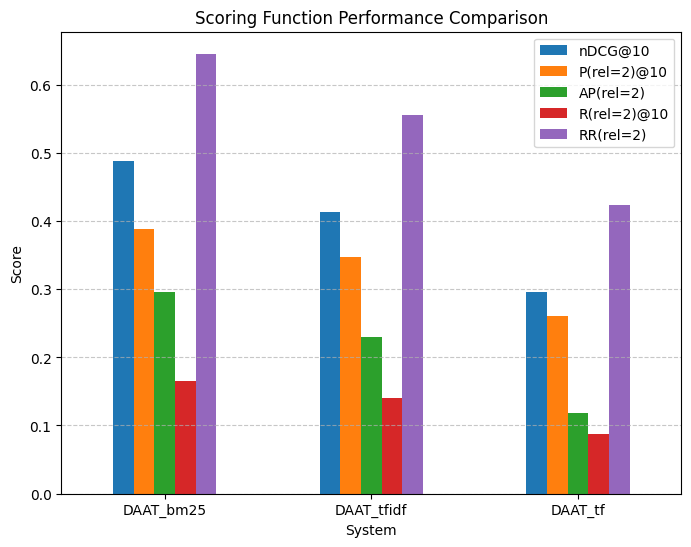

In [ ]:
# Transpose the DataFrame (.T) so systems are on the x-axis
ax = results_df.T.plot(
    kind='bar',
    figsize=(8, 6),
    rot=0,  # Keeps x-axis labels horizontal
    title='Scoring Function Performance Comparison'
)
ax.set_ylabel("Score")
ax.set_xlabel("System")
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

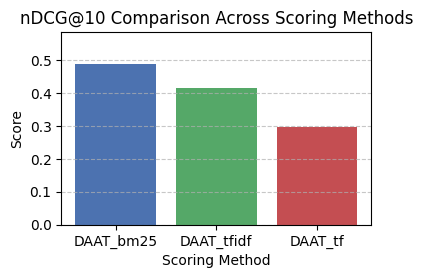

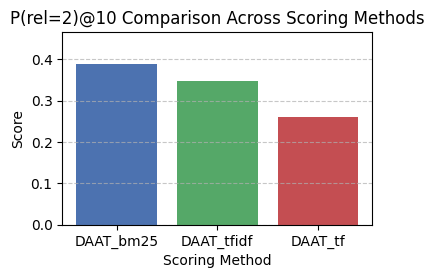

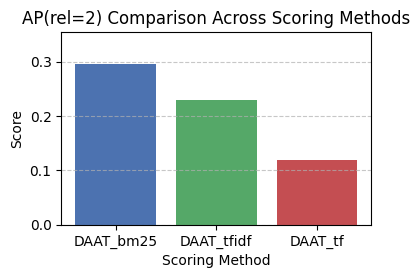

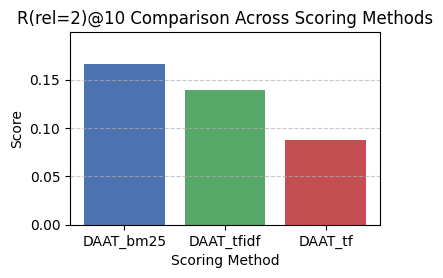

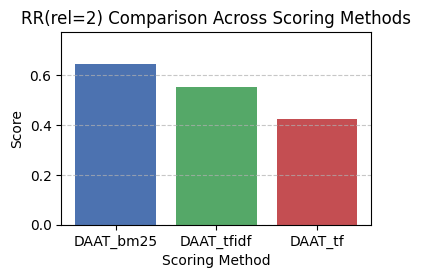

In [ ]:
# Create separate bar charts for each metric
for metric in results_df.index:
    plt.figure(figsize=(4, 2.5))
    plt.bar(results_df.columns, results_df.loc[metric], color=['#4C72B0', '#55A868', '#C44E52'])
    plt.title(f"{metric} Comparison Across Scoring Methods")
    plt.xlabel("Scoring Method")
    plt.ylabel("Score")
    plt.ylim(0, max(results_df.loc[metric]) * 1.2)  # Add headroom above bars
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


This visualization provides a bar chart comparison of the overall performance of the three DAAT systems — BM25, TF-IDF, and TF — across all evaluation metrics.

By transposing the results table, each system appears on the x-axis, while bars represent metric scores (e.g., nDCG@10, AP, RR). This helps visually compare how well each ranking model performs in terms of relevance and ranking quality.

### Interpretation of Results

**BM25** outperforms both **TF-IDF** and **TF** across all evaluation metrics, confirming its effectiveness as a ranking model that balances term frequency, document length normalization, and term rarity (IDF).  

**TF-IDF** performs moderately, benefiting from term weighting but lacking BM25’s normalization and saturation controls.  

The simple **TF** approach performs the worst overall, as it does not account for document or term distribution, leading to less discriminative ranking.


## 7.1 Conclusion

This project implemented and evaluated custom **Document-at-a-Time (DAAT)** retrieval systems using three scoring models — **BM25**, **TF-IDF**, and **TF** — on the **TREC Deep Learning 2019 Passage Ranking** dataset, derived from the **MS MARCO passage collection** containing over **8.8 million passages**. The dataset includes 200 evaluation queries with graded relevance judgments, making it a robust benchmark for large-scale passage retrieval experiments.

The evaluation employed standard IR metrics — **nDCG@10**, **AP(rel=2)**, **RR(rel=2)**, **P@10**, and **R@10** — to assess the effectiveness of each scoring model.  

The results show that **BM25 consistently outperforms both TF-IDF and TF** across all evaluation metrics, validating its strength in balancing term frequency, document length normalization, and term rarity (IDF). **TF-IDF** achieves moderate performance by leveraging term weighting, while **TF**, the simplest model, performs the weakest due to the absence of normalization and weighting mechanisms.

Overall, the findings confirm **BM25** as the most effective traditional retrieval model for large-scale datasets like MS MARCO. Future work could explore **neural ranking models**, **query expansion**, or **hybrid retrieval approaches** to further enhance retrieval accuracy and relevance.
